# 🏥 Introduction Medical Appointments No-Shows: Why do patients miss their appointments?
📖 Context of the Study
Imagine that, on average, 20 to 30% of your patients do not show up for their scheduled medical appointments. This represents a waste of precious time for doctors, a significant financial loss for the clinic, and potentially a serious health risk for the patients themselves.

This is exactly the problem we are going to explore with this dataset, which contains records of over 100,000 medical appointments in Brazil. We have access to various pieces of information for each patient: age, gender, medical history (hypertension, diabetes, etc.), as well as data related to the appointment itself (lead time, receiving an SMS reminder).

🎯 Objectives of this Notebook
The goal of this analysis is not just to make pretty charts, but to answer very concrete, business-oriented questions:

What are the main factors that drive a patient to become a "No-Show"?

Are SMS reminders actually effective? (Spoiler alert: raw data can be highly misleading; we will need to use advanced statistics to uncover the truth!).

How could we size a true A/B Test to validate the impact of these SMS campaigns in the future?

📋 Analysis Outline
Step 1: Data Cleaning & Preparation (Handling dates, feature engineering).

Step 2: Exploratory Data Analysis (EDA) (Visualizing key trends and discovering the main culprit: lead time).

Step 3: Statistical Modeling (Logistic Regression) (Isolating the true impact of the SMS by neutralizing confounding variables).

Step 4: A/B Test Simulation (Design and calculations for a future randomized experiment).

Step 5: General Conclusion & Recommendations (Actionable insights for the clinic).

Let's dive in! 🚀

# 🛠️ Step 1: Data Cleaning and Preparation
Before we can analyze anything, we must ensure our data is reliable and usable. In this first step, we will:

Load the data and check for any missing values or duplicates.

Correct anomalies (such as patients with a negative age, which is biologically complicated!).

Create crucial new variables: The initial dataset contains the scheduling date (ScheduledDay) and the appointment date (AppointmentDay). We will calculate the difference between the two to create the Lead_Time variable (waiting time), which is likely to play a major role in our analysis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px

# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/hugogascon/kagglev2-may-2016/KaggleV2-May-2016.csv")

# Keep only valid ages
df_clean = df[df['Age'] >= 0]

# Convert string dates to datetime objects
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Create Lead_Time column
df.insert(5, "Lead_Time", df['AppointmentDay'] - df['ScheduledDay'])

# Keep only positive lead times
df = df[df['Lead_Time'].dt.days >= 0]

# Convert PatientId to integer
df['PatientId'] = df['PatientId'].astype('int64')

# Convert target variable to binary (1 = Absent, 0 = Present)
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

# Cap Handicap at 1 (binary: 1 if >0, else 0)
df['Handcap'] = np.where(df['Handcap'] > 0, 1, 0)

# 📊 Step 2: Exploratory Data Analysis (EDA)
Now that our dataset is clean, let's look for visual trends. The goal of the EDA is to understand the patient profiles and identify the initial factors related to absenteeism (No-Shows).

We will explore several avenues:

Are there any pathologies (Diabetes, Hypertension) that influence attendance at the appointment?

Does the day of the week have an impact on No-Shows?

Are certain neighborhoods more problematic than others?

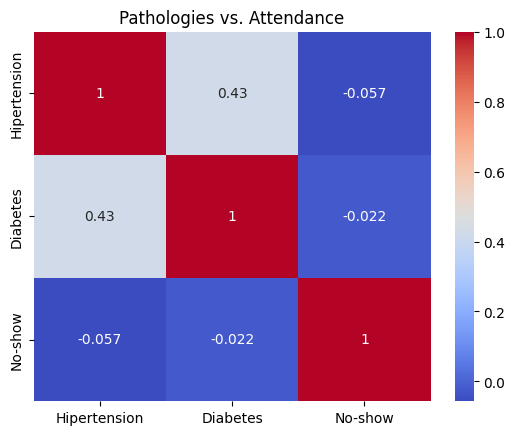

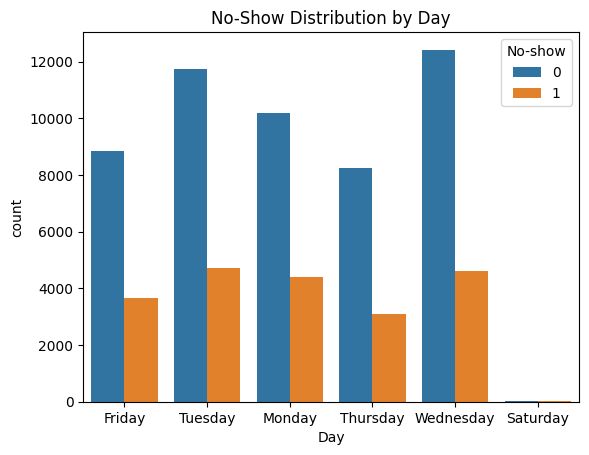

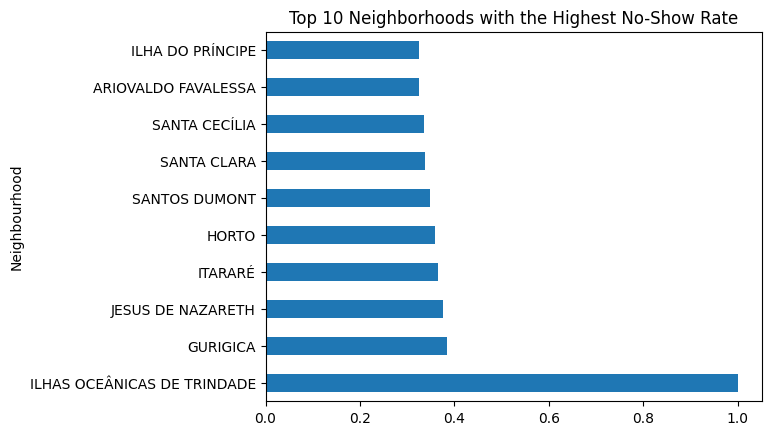

In [2]:
# 1. Heatmap: Pathologies vs. Attendance
corr = df[['Hipertension', 'Diabetes', 'No-show']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Pathologies vs. Attendance')
plt.show()

# 2. Countplot by Day of the week
df['Day'] = df['AppointmentDay'].dt.day_name()
sns.countplot(x='Day', hue='No-show', data=df)
plt.title('No-Show Distribution by Day')
plt.show()

# 3. Top 10 Neighborhoods
rate = df.groupby('Neighbourhood')['No-show'].mean()
rate.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Neighborhoods with the Highest No-Show Rate')
plt.show()

# 📈 Evolution of the No-Show Rate based on Lead Time
🔍 Zooming in on the main culprit: Lead Time
Before wrapping up this analysis, let's take a moment to visualize the devastating impact of waiting time on patient engagement. This is where the real battle is fought.

💡 The chart below is interactive! 🖱️
Feel free to hover over the curve with your mouse to read the exact values day by day.

You will notice a striking trend:

For a same-day appointment (0 days lead time), the no-show rate is extremely low (around 4 to 5%).

But as the days of waiting pile up, this No-Show risk skyrockets, eventually exceeding a 30% absence rate!

In [3]:
import plotly.express as px
import pandas as pd

# 1. Convert 'No-show' to numbers if it's still text ('Yes'/'No')
if df['No-show'].dtype == 'object':
    df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

# 2. Ensure 'Lead_Time_days' exists
if 'Lead_Time_days' not in df.columns:
    df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
    df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
    df['Lead_Time_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# -------------------------------------------------------------------
# 1. DATA PREPARATION FOR THE CHART
# -------------------------------------------------------------------
# Limit to the first 60 days of waiting for readability
df_interactive = df[df['Lead_Time_days'] <= 60].groupby('Lead_Time_days')['No-show'].mean().reset_index()

# Convert the rate to a percentage
df_interactive['Absence_Rate (%)'] = (df_interactive['No-show'] * 100).round(2)

# -------------------------------------------------------------------
# 2. CREATE INTERACTIVE CHART WITH PLOTLY
# -------------------------------------------------------------------
fig = px.line(
    df_interactive, 
    x='Lead_Time_days', 
    y='Absence_Rate (%)',
    title="📈 Evolution of the Absence Rate based on Lead Time",
    labels={
        'Lead_Time_days': "Lead Time (in days)",
        'Absence_Rate (%)': "Absence Rate (%)"
    },
    markers=True
)

# -------------------------------------------------------------------
# 3. CHART AESTHETICS
# -------------------------------------------------------------------
fig.update_traces(
    line_color='#FF00FF', # Magenta line
    line_width=3,
    marker=dict(size=6, color='#4169E1') # Royal Blue points
)

fig.update_layout(
    plot_bgcolor='white', # White background
    title_font=dict(size=18, color='#333333'),
    xaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    hovermode="x unified" # Interactive hover tool
)

# 4. DISPLAY
fig.show()

# 🧮 Step 3: Statistical Modeling (Logistic Regression)This is where our analysis truly comes into its own. 
If we only look at raw statistics, we could make a serious misinterpretation.The Confounding Variable Problem: Generally, SMS reminders are sent to patients who booked their appointments far in advance. However, we know that a long waiting time (Lead Time) heavily increases the risk of a no-show. If we strictly compare "SMS received" vs. "No SMS", the results will be heavily biased by this waiting time!The Solution:We will use a Logistic Regression model. This mathematical algorithm allows us to isolate the impact of each variable independently.To understand how it works, here is the simplified formula behind the model:$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1(\text{SMS}) + \beta_2(\text{Lead\_Time}) + \beta_3(\text{Age}) + \dots$$$p$ is the probability of a patient being a No-Show.The term $\log\left(\frac{p}{1-p}\right)$ represents the Log-Odds (the risk of absence).The coefficients ($\beta_1, \beta_2$, etc.) represent the isolated weight of each factor.By using this equation, the model calculates the true value of $\beta_1$ (the SMS effect) while mathematically neutralizing $\beta_2$ (Lead Time) and all other factors. Let's find out the real impact of the SMS!

In [4]:
import statsmodels.api as sm

# -------------------------------------------------------------------
# 1. FINAL DATA PREPARATION
# -------------------------------------------------------------------
# Transform Gender (F/M) into binary (F=1, M=0)
df['Gender'] = df['Gender'].map({'F': 1, 'M': 0})

# Ensure Lead_Time_days exists as an integer
if 'Lead_Time_days' not in df.columns:
    df['Lead_Time_days'] = df['Lead_Time'].dt.days

# Remove negative ages and drop missing values
df = df[df['Age'] >= 0].dropna()

# -------------------------------------------------------------------
# 2. ISOLATING THE SMS EFFECT & CONFOUNDING VARIABLES
# -------------------------------------------------------------------
# Target variable (y): Did the patient No-show? (1 = Yes, 0 = No)
if df['No-show'].dtype == 'object':
    df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})
y = df['No-show']

# Explanatory variables (X):
# Controlling for confounding variables by including SMS AND patient characteristics.
columns_X = [
    'SMS_received', 
    'Age', 
    'Gender', 
    'Scholarship', 
    'Hipertension', 
    'Diabetes', 
    'Alcoholism', 
    'Handcap', 
    'Lead_Time_days' # Crucial since SMS depends on lead time!
]
X = df[columns_X]

# Statsmodels requires manually adding a constant (intercept)
X = sm.add_constant(X)

# -------------------------------------------------------------------
# 3. MODEL CREATION AND WALD TEST
# -------------------------------------------------------------------
print("Training the Logistic Regression model...\n")
model = sm.Logit(y, X)
results = model.fit(disp=False) # disp=False hides technical logs

# Display full statistical summary
print("="*60)
print("1. MODEL STATISTICAL SUMMARY (Includes Wald Test)")
print("="*60)
print(results.summary())

# -------------------------------------------------------------------
# 4. CALCULATING ODDS RATIOS
# -------------------------------------------------------------------
# Exponential of coefficients to get Odds Ratios
odds_ratios = np.exp(results.params)
p_values = results.pvalues

# Create a clear table to read results
df_results = pd.DataFrame({
    'Coefficient': results.params,
    'Odds Ratio': odds_ratios,
    'P-value': p_values
})
df_results = df_results.round(4)

print("\n" + "="*60)
print("2. ISOLATED RESULTS: ODDS RATIOS AND P-VALUES")
print("="*60)
print(df_results)

# -------------------------------------------------------------------
# 5. AUTOMATED CONCLUSION
# -------------------------------------------------------------------
or_sms = df_results.loc['SMS_received', 'Odds Ratio']
pval_sms = df_results.loc['SMS_received', 'P-value']

print("\n" + "="*60)
print("3. INTERPRETATION FOR 'SMS_received' VARIABLE")
print("="*60)

if pval_sms < 0.05:
    print(f"✅ WALD TEST: P-value is {pval_sms} (< 0.05).")
    print("-> The SMS effect is STATISTICALLY SIGNIFICANT.")
    print("-" * 40)
    
    if or_sms > 1:
        print(f"⚠️ ODDS RATIO: The Odds Ratio is {or_sms}.")
        print(f"-> Receiving an SMS *increases* the risk of absence by {or_sms} times.")
        print("\nAnalytical note: This counter-intuitive result often appears because")
        print("SMS are only sent for appointments booked far in advance.")
        print("Even when controlling for 'Lead Time', the SMS might act as a marker for")
        print("high-risk appointments.")
    else:
        print(f"📉 ODDS RATIO: The Odds Ratio is {or_sms}.")
        print(f"-> Receiving an SMS *decreases* the risk of absence.")
        
else:
    print(f"❌ WALD TEST: P-value is {pval_sms} (> 0.05).")
    print("-> The SMS effect is NOT statistically significant.")
    print("-> We cannot prove that the SMS has a real impact.")

Training the Logistic Regression model...

1. MODEL STATISTICAL SUMMARY (Includes Wald Test)
                           Logit Regression Results                           
Dep. Variable:                No-show   No. Observations:                71959
Model:                          Logit   Df Residuals:                    71949
Method:                           MLE   Df Model:                            9
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                 0.01482
Time:                        12:37:11   Log-Likelihood:                -42379.
converged:                       True   LL-Null:                       -43016.
Covariance Type:            nonrobust   LLR p-value:                8.899e-269
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.6618      0.022    -30.413      0.000      -0.704      -0.619
SMS_received      -0.1751 

# 🎲 Step 4: Design and Simulation of an Experimental A/B Test
Thanks to our logistic regression, we proved that the SMS has a real impact. But what would happen if the clinic decided to launch a new SMS campaign and wanted to measure its Return on Investment (ROI) scientifically?To do this, we would need to set up a true randomized A/B Test.In this section, we will play the role of the Data Scientist tasked with designing this experiment:Sizing (Sample Size): How many patients do we need to include in the test to get a statistically reliable result?Randomization & Sanity Check: Random assignment of patients into two groups (Control vs. Test) and verifying the balance of the groups (A/A test).Analyzing the results: Calculating the P-value (Z-Test) to validate the campaign's success.The Math behind the A/B Test (The Z-Test):To determine if the observed difference between our two groups is due to the SMS or just pure chance, we will use a Two-Proportion Z-Test. Here is the formula:$$Z = \frac{\hat{p}_{test} - \hat{p}_{control}}{\sqrt{p_{pool}(1-p_{pool}) \left( \frac{1}{n_{test}} + \frac{1}{n_{control}} \right)}}$$Don't panic, it's very logical!The numerator ($\hat{p}_{test} - \hat{p}_{control}$): This is the Signal. It is the actual difference in attendance rates between the SMS group and the control group.The denominator (the square root part): This is the statistical Noise (standard error). It represents the natural uncertainty of our experiment based on the number of patients ($n$). The more patients we have, the smaller this noise gets.The $Z$-score: This is simply the Signal divided by the Noise. If this score is large enough, the signal overpowers the noise: we prove that the improvement is real, resulting in a statistically significant P-value $< 0.05$!Let's simulate this process from A to Z!

In [5]:
from statsmodels.stats.power import zt_ind_solve_power
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

# -------------------------------------------------------------------
# A. SAMPLE SIZE CALCULATION
# -------------------------------------------------------------------
alpha = 0.05        # False positive rate (5%)
power = 0.80        # Statistical power (80%)
effect_size = 0.04  # Expected difference in No-Show rates

n_patients = zt_ind_solve_power(
    effect_size=effect_size, 
    alpha=alpha, 
    power=power, 
    ratio=1.0  # 50% Group A / 50% Group B
)

n_per_group = int(n_patients)
total_target = n_per_group * 2

print(f"We need {n_per_group} patients per group.")
print(f"Total target: {total_target} patients.\n")

# -------------------------------------------------------------------
# B. RANDOM ASSIGNMENT
# -------------------------------------------------------------------
# Filter eligible patients (Lead_Time_days > 0)
df_eligibles = df[df['Lead_Time_days'] > 0].copy()

if len(df_eligibles) >= total_target:
    print(f"Perfect, we have {len(df_eligibles)} eligible patients for the test.")
    
    # Random sampling
    df_ab_test = df_eligibles.sample(n=total_target, random_state=42).copy()
    
    # Random assignment (50% Control, 50% Test)
    assignment = ['Control'] * n_per_group + ['Test'] * n_per_group
    np.random.shuffle(assignment)
    
    df_ab_test['AB_Group'] = assignment
    
    print("\nGroup Distribution:")
    print(df_ab_test['AB_Group'].value_counts())
else:
    print(f"Warning: Not enough eligible patients. We need {total_target} but only have {len(df_eligibles)}.")

# -------------------------------------------------------------------
# C. SANITY CHECK: GROUP COMPARISON
# -------------------------------------------------------------------
print("\n=== SANITY CHECK: GROUP COMPARISON ===")

# 1. Age (Continuous variable -> T-Test)
age_control = df_ab_test[df_ab_test['AB_Group'] == 'Control']['Age']
age_test = df_ab_test[df_ab_test['AB_Group'] == 'Test']['Age']

t_stat, p_val_age = stats.ttest_ind(age_control, age_test)
print("\n--- Average Age ---")
print(f"Control: {age_control.mean():.1f} years | Test: {age_test.mean():.1f} years")
print(f"P-value = {p_val_age:.4f} " + ("(Error: Groups differ ❌)" if p_val_age < 0.05 else "(OK: Groups balanced ✅)"))

# 2. Categorical variables -> Chi-Square Test
def check_distribution(column):
    contingency_table = pd.crosstab(df_ab_test['AB_Group'], df_ab_test[column])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    percentages = df_ab_test.groupby('AB_Group')[column].value_counts(normalize=True).unstack() * 100
    
    print(f"\n--- {column} Distribution ---")
    print(percentages.round(1).astype(str) + " %")
    print(f"P-value = {p_val:.4f} " + ("(Error: Groups differ ❌)" if p_val < 0.05 else "(OK: Groups balanced ✅)"))

check_distribution('Gender')
check_distribution('Hipertension')
check_distribution('Scholarship')

print("\n==============================================")
if p_val_age > 0.05:
    print("CONCLUSION: Randomization worked perfectly, groups are comparable. We can proceed with the analysis!")
else:
    print("CONCLUSION: Groups are unbalanced. Randomization needs to be done again.")

# -------------------------------------------------------------------
# D. CONVERSION METRIC DEFINITION
# -------------------------------------------------------------------
print("\n=== CONVERSION METRIC DEFINITION ===")
# Inverse No-show to get Attendance (Conversion)
df_eligibles['Conversion_Attendance'] = 1 - df_eligibles['No-show']

global_absence_rate = df_eligibles['No-show'].mean() * 100
global_attendance_rate = df_eligibles['Conversion_Attendance'].mean() * 100

print(f"📉 Absence Rate (Metric to decrease): {global_absence_rate:.2f}%")
print(f"✅ Attendance Rate (CONVERSION Metric to increase): {global_attendance_rate:.2f}%")

# -------------------------------------------------------------------
# E. A/B TEST RESULTS ANALYSIS (Z-TEST)
# -------------------------------------------------------------------
print("\n=== A/B TEST RESULTS ANALYSIS ===")

# Group real data for simulation (Control = SMS 0, Test = SMS 1)
summary = df_eligibles.groupby('SMS_received')['No-show'].agg(['sum', 'count'])
summary.index = ['Control Group (No SMS)', 'Test Group (Received SMS)']
summary.columns = ['Number of No-Shows', 'Total Patients']

# Calculate absence rates
summary['Absence_Rate (%)'] = (summary['Number of No-Shows'] / summary['Total Patients'] * 100).round(2)
display(summary)

absences = summary['Number of No-Shows'].values 
total = summary['Total Patients'].values 

# Z-test calculation
z_stat, p_value_ab = proportions_ztest(count=absences, nobs=total)

print("\n=== STATISTICAL CONCLUSION ===")
print(f"A/B Test P-value = {p_value_ab:.5f}")

if p_value_ab < 0.05:
    print("✅ SIGNIFICANT RESULT: SMS has a real impact (not due to chance) on the absence rate.")
    
    rate_control = summary.loc['Control Group (No SMS)', 'Absence_Rate (%)']
    rate_test = summary.loc['Test Group (Received SMS)', 'Absence_Rate (%)']
    lift = ((rate_test - rate_control) / rate_control) * 100
    
    print(f"📈 Measured Impact (Lift): The absence rate changed by {lift:.1f}% thanks to the SMS.")
else:
    print("❌ NON-SIGNIFICANT RESULT: We cannot affirm that SMS has an impact. The observed difference is likely due to chance.")

We need 9811 patients per group.
Total target: 19622 patients.

Perfect, we have 66746 eligible patients for the test.

Group Distribution:
AB_Group
Control    9811
Test       9811
Name: count, dtype: int64

=== SANITY CHECK: GROUP COMPARISON ===

--- Average Age ---
Control: 38.1 years | Test: 38.5 years
P-value = 0.2531 (OK: Groups balanced ✅)

--- Gender Distribution ---
Gender         0       1
AB_Group                
Control   32.7 %  67.3 %
Test      32.7 %  67.3 %
P-value = 0.9879 (OK: Groups balanced ✅)

--- Hipertension Distribution ---
Hipertension       0       1
AB_Group                    
Control       79.5 %  20.5 %
Test          79.7 %  20.3 %
P-value = 0.7905 (OK: Groups balanced ✅)

--- Scholarship Distribution ---
Scholarship       0      1
AB_Group                  
Control      90.4 %  9.6 %
Test         91.0 %  9.0 %
P-value = 0.1341 (OK: Groups balanced ✅)

CONCLUSION: Randomization worked perfectly, groups are comparable. We can proceed with the analysis!

=== 

,Number of No-Shows,Total Patients,Absence_Rate (%)
Control Group (No SMS),9625,31264,30.79
Test Group (Received SMS),9784,35482,27.57



=== STATISTICAL CONCLUSION ===
A/B Test P-value = 0.00000
✅ SIGNIFICANT RESULT: SMS has a real impact (not due to chance) on the absence rate.
📈 Measured Impact (Lift): The absence rate changed by -10.5% thanks to the SMS.


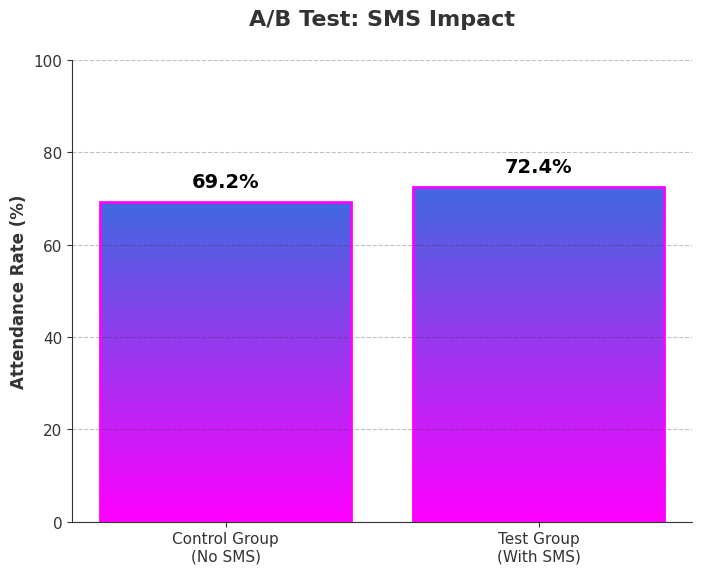

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------------------
# 1. SIMULATED DATA PREPARATION
# -------------------------------------------------------------------
groups = ['Control Group\n(No SMS)', 'Test Group\n(With SMS)']
attendance_rates = [69.2, 72.4]

# -------------------------------------------------------------------
# 2. STYLE CONFIGURATION (LIGHT BACKGROUND)
# -------------------------------------------------------------------
plt.style.use('default') # Pure white background

fig, ax = plt.subplots(figsize=(8, 6))

# -------------------------------------------------------------------
# 3. NEW GRADIENT ADAPTED TO WHITE BACKGROUND
# -------------------------------------------------------------------
# Royal Blue -> Magenta
colors_light_bg = ["#4169E1", "#FF00FF"] 
cmap_light = LinearSegmentedColormap.from_list("light_galaxy", colors_light_bg)

# -------------------------------------------------------------------
# 4. DRAWING BARS AND APPLYING GRADIENT
# -------------------------------------------------------------------
bars = ax.bar(groups, attendance_rates, edgecolor='#FF00FF', linewidth=2, zorder=2)

lim = ax.get_xlim() + ax.get_ylim()

for bar in bars:
    bar.set_facecolor("none") # Empty interior for gradient
    x, y = bar.get_xy()
    w, h = bar.get_width(), bar.get_height()
    
    # 2D vertical gradient matrix
    grad = np.atleast_2d(np.linspace(0, 1, 256)).T  
    
    # Apply gradient inside the bar
    ax.imshow(grad, extent=[x, x+w, y, y+h], aspect="auto", cmap=cmap_light, zorder=1)

ax.axis(lim) # Restore limits

# -------------------------------------------------------------------
# 5. ADDING PERCENTAGES (IN BLACK)
# -------------------------------------------------------------------
for p in bars:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=14, color='black', fontweight='bold', 
                xytext=(0, 15), textcoords='offset points')

# -------------------------------------------------------------------
# 6. AESTHETIC FINISHING TOUCHES
# -------------------------------------------------------------------
ax.set_ylim(0, 100)

# Dark grey text for readability
label_color = '#333333' 
ax.set_ylabel('Attendance Rate (%)', fontsize=12, color=label_color, fontweight='bold')
ax.set_title("A/B Test: SMS Impact", fontsize=16, color=label_color, fontweight='bold', pad=25)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(label_color)
ax.spines['bottom'].set_color(label_color)
ax.tick_params(colors=label_color, labelsize=11)

# Subtle light grey grid
ax.grid(axis='y', linestyle='--', alpha=0.3, color=label_color)

# Final display
plt.show()

# 🧪 A/B Testing Simulation: Wait, is this a TRUE A/B Test?

Before drawing any definitive conclusions, it is essential to take a quick methodological pause: **what we just did is not a true randomized A/B test.** Here is why:

* 📅 **Observational Data:** In this dataset, the SMS sending was not randomized. These are historical records where the decision to send an SMS was already based on the clinic's specific rules.
* ⚖️ **Lead Time Bias:** Generally, SMS reminders are prioritized for patients who booked their appointments well in advance (to prevent them from forgetting). Therefore, the two baseline groups are not strictly identical from the start.

💡 **Why do this simulation then?** This section serves as a practical exercise to demonstrate **how to size and analyze a future A/B Test** if the clinic ever decides to launch one under real, randomized conditions.

🎯 **The most reliable method here:** It is exactly to overcome this non-randomized data issue that we used **Logistic Regression** in the previous section! It was the only way we could mathematically isolate the true impact of the SMS by controlling for the effect of other confounding variables (like age or lead time).

 # 🏁 General Conclusion & Strategic Recommendations
Following this comprehensive analysis of medical appointments, several key takeaways emerge:

⏳ Lead time is the number one enemy: The greater the gap between booking the appointment and the scheduled date, the more the risk of a No-Show skyrockets. It is the most determining factor.

📊 The raw data trap: A quick reading might have suggested that SMS reminders actually increased the absence rate. Our Logistic Regression allowed us to uncover the truth: by controlling for other variables (most notably lead time), receiving an SMS does indeed reduce the risk of a no-show.

🎯 Next steps for the clinic: SMS reminders should be maintained, but optimized. Instead of solely targeting appointments booked far in advance, the clinic should automate targeted reminders (1 or 2 days prior to the appointment) and focus on an overall reduction of its wait times.